In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# 1. Definição e Carregamento de todas as bases de dados
# (Certifique-se de que os arquivos .csv estão na mesma pasta do seu notebook)
df_reservas = pd.read_csv('reservas.csv', sep=';')
df_unidades = pd.read_csv('unidades.csv', sep=';')
df_tipos_quarto = pd.read_csv('tipos_quarto.csv', sep=';')
df_clientes = pd.read_csv('clientes.csv', sep=';')
df_canais = pd.read_csv('canais_venda.csv', sep=';')
df_funcionarios = pd.read_csv('funcionarios.csv', sep=';')

In [4]:
# 1. Cruzamento para calcular o faturamento real por reserva
df_merged = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')
df_merged = df_merged.merge(df_unidades[['id_unidade', 'nome_unidade', 'regiao']], on='id_unidade', how='left')
df_merged['faturamento_reserva'] = df_merged['qtd_diarias'] * df_merged['valor_diaria_base']



In [5]:
# 2. Medindo a discrepância estatística: Agrupamento com métricas resumo
resumo_estatistico = df_merged.groupby('nome_unidade')['faturamento_reserva'].agg(['count', 'mean', 'median', 'std', 'sum']).reset_index()
resumo_estatistico.columns = ['Unidade', 'Qtd Reservas', 'Faturamento Médio', 'Mediana', 'Desvio Padrão', 'Faturamento Total']
resumo_estatistico = resumo_estatistico.sort_values(by='Faturamento Total', ascending=False)

# Formatando a tabela resumo para apresentação executiva
tabela_discrepancia = resumo_estatistico.copy()
tabela_discrepancia['Faturamento Médio'] = tabela_discrepancia['Faturamento Médio'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
tabela_discrepancia['Faturamento Total'] = tabela_discrepancia['Faturamento Total'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

display(tabela_discrepancia)



,Unidade,Qtd Reservas,Faturamento Médio,Mediana,Desvio Padrão,Faturamento Total
8,NaraHoteis Paraty,215,"R$ 2.473,30",1900.0,2042.183818,"R$ 531.760,00"
3,NaraHoteis Friburgo,208,"R$ 2.464,57",1960.0,1908.310026,"R$ 512.630,00"
7,NaraHoteis Nova Iguaçu Park,197,"R$ 2.532,64",1900.0,2112.393491,"R$ 498.930,00"
11,NaraHoteis Teresópolis,181,"R$ 2.743,48",2100.0,2229.444260,"R$ 496.570,00"
10,NaraHoteis Santa Teresa,214,"R$ 2.309,44",1740.0,1867.607659,"R$ 494.220,00"
9,NaraHoteis Petrópolis,195,"R$ 2.478,46",1900.0,2085.593612,"R$ 483.300,00"
1,NaraHoteis Barra da Tijuca,184,"R$ 2.566,30",1820.0,2193.678059,"R$ 472.200,00"
5,NaraHoteis Mangaratiba,200,"R$ 2.334,30",1710.0,1883.240688,"R$ 466.860,00"
0,NaraHoteis Angra dos Reis,185,"R$ 2.393,57",1740.0,1943.163665,"R$ 442.810,00"
4,NaraHoteis Ipanema,186,"R$ 2.296,13",1740.0,1751.409645,"R$ 427.080,00"


C:\Users\Robert\AppData\Local\Temp\ipykernel_4628\1496417274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='nome_unidade', y='faturamento_reserva', palette='Set3')


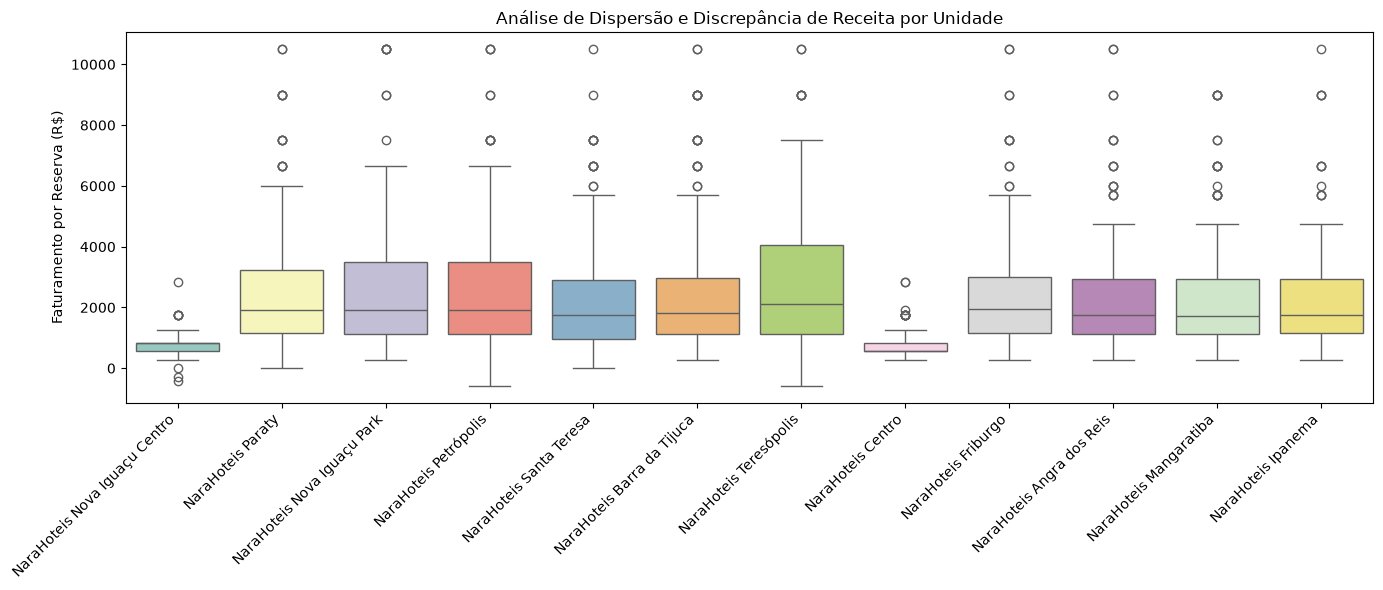

In [6]:

# 3. Visualização Gráfica: Boxplot de Faturamento por Unidade
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_merged, x='nome_unidade', y='faturamento_reserva', palette='Set3')
plt.title('Análise de Dispersão e Discrepância de Receita por Unidade')
plt.xlabel('')
plt.ylabel('Faturamento por Reserva (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Os dados revelam uma divisão muito clara no comportamento da rede:

O motor do negócio (Lazer): Unidades como Paraty, Friburgo e Nova Iguaçu Park lideram o faturamento (acima de R$ 490 mil). O ponto forte delas é o valor por reserva, que fica entre R$ 2.400 e R$ 2.700, mostrando estadias mais longas ou de maior valor agregado.

O ponto de atenção (Unidades Centro): As filiais NaraHoteis Centro e Nova Iguaçu Centro até recebem um bom volume de hóspedes, mas o faturamento médio desaba para cerca de R$ 700 por reserva. Por isso, o faturamento total delas não chega a R$ 200 mil.

Visão para a diretoria:
O problema de receita da rede não está espalhado por igual. O modelo voltado para áreas centrais e estadias rápidas perdeu força na receita unitária, enquanto o turismo de lazer sustenta os melhores resultados da NaraHoteis.

In [7]:
# 1. Calculando o Faturamento Total da Rede e a Participação Percentual por Unidade
faturamento_total_rede = resumo_estatistico['Faturamento Total'].sum()

resumo_estatistico['Participação Rede (%)'] = (resumo_estatistico['Faturamento Total'] / faturamento_total_rede) * 100

# 2. Calculando a Curva ABC Acumulada
resumo_estatistico = resumo_estatistico.sort_values(by='Faturamento Total', ascending=False)
resumo_estatistico['Participação Acumulada (%)'] = resumo_estatistico['Participação Rede (%)'].cumsum()

# 3. Formatando para visualização executiva
tabela_abc = resumo_estatistico[['Unidade', 'Faturamento Total', 'Participação Rede (%)', 'Participação Acumulada (%)']].copy()
tabela_abc['Faturamento Total'] = tabela_abc['Faturamento Total'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
tabela_abc['Participação Rede (%)'] = tabela_abc['Participação Rede (%)'].apply(lambda x: f"{x:.2f}%")
tabela_abc['Participação Acumulada (%)'] = tabela_abc['Participação Acumulada (%)'].apply(lambda x: f"{x:.2f}%")

display(tabela_abc)

,Unidade,Faturamento Total,Participação Rede (%),Participação Acumulada (%)
8,NaraHoteis Paraty,"R$ 531.760,00",10.25%,10.25%
3,NaraHoteis Friburgo,"R$ 512.630,00",9.88%,20.13%
7,NaraHoteis Nova Iguaçu Park,"R$ 498.930,00",9.62%,29.75%
11,NaraHoteis Teresópolis,"R$ 496.570,00",9.57%,39.33%
10,NaraHoteis Santa Teresa,"R$ 494.220,00",9.53%,48.85%
9,NaraHoteis Petrópolis,"R$ 483.300,00",9.32%,58.17%
1,NaraHoteis Barra da Tijuca,"R$ 472.200,00",9.10%,67.27%
5,NaraHoteis Mangaratiba,"R$ 466.860,00",9.00%,76.27%
0,NaraHoteis Angra dos Reis,"R$ 442.810,00",8.54%,84.81%
4,NaraHoteis Ipanema,"R$ 427.080,00",8.23%,93.04%
